In [19]:
import pandas as pd

In [20]:
data = pd.read_parquet("test_set_new2.parquet")
print(data.shape)
data.head(20)

(190237, 180)


,stay_id,timestep,sepsis,age,gender,charlson_comorbidity_index,heart_rate,map,respiratory_rate,temp_C,...,respiratory_rate_min_16h,temp_C_min_16h,spo2_min_16h,wbc_min_16h,lactate_min_16h,creatinine_min_16h,platelets_min_16h,sirs_score_min_16h,shock_index_min_16h,target
0,30000646,1,0,44.0,0,6,72.000000,90.333336,16.500000,36.518520,...,16.500000,36.518520,99.750000,2.230014,2.490000,1.000000,250.000000,0.0,0.646707,0
1,30000646,2,0,44.0,0,6,84.670746,79.246231,19.214134,36.856297,...,16.500000,36.518520,96.607025,2.230014,2.235202,1.000000,200.269836,0.0,0.646707,0
2,30000646,3,0,44.0,0,6,84.670746,79.246231,19.214134,36.856297,...,16.500000,36.518520,96.607025,2.230014,2.235202,1.000000,200.269836,0.0,0.646707,0
3,30000646,4,0,44.0,0,6,84.670746,79.246231,19.214134,36.856297,...,16.500000,36.518520,96.607025,2.230014,2.235202,1.000000,200.269836,0.0,0.646707,0
4,30000646,5,0,44.0,0,6,100.333336,76.666664,28.833334,37.000000,...,19.214134,36.856297,96.607025,2.230014,1.600000,1.000000,200.269836,1.0,0.711384,0
5,30000646,6,0,44.0,0,6,91.000000,60.642857,28.071428,37.373016,...,19.214134,36.856297,95.571426,2.230014,0.700000,0.942857,200.269836,1.0,0.711384,0
6,30000646,7,0,44.0,0,6,90.238098,64.523811,30.952381,38.682541,...,19.214134,36.856297,93.809525,2.230014,0.700000,0.942857,200.269836,1.0,0.711384,0
7,30000646,8,0,44.0,0,6,71.250000,64.000000,17.500000,37.222221,...,17.500000,37.000000,93.809525,2.230014,0.700000,0.942857,250.000000,1.0,0.796089,0
8,30000646,9,0,44.0,0,6,77.000000,72.599998,19.799999,36.666668,...,17.500000,36.666668,93.809525,2.341806,0.700000,0.942857,297.571442,1.0,0.776210,0
9,30000646,10,0,44.0,0,6,82.823532,64.117645,23.588236,36.843136,...,17.500000,36.666668,93.809525,2.271519,1.600000,0.717647,286.882355,1.0,0.776210,0


In [18]:
data.loc[:, ['stay_id', 'timestep', 'sepsis', 'target']]
# data[data['sepsis'] != 0][['stay_id', 'timestep', 'sepsis', 'target']]

,stay_id,timestep,sepsis,target
0,30000646,1,0,0
1,30000646,2,0,0
2,30000646,3,0,0
3,30000646,4,0,0
4,30000646,5,0,0
...,...,...,...,...
190232,39999384,6,0,0
190233,39999384,7,0,0
190234,39999384,8,0,0
190235,39999384,9,0,0


In [35]:
TARGET_COL = 'target'
PATIENT_ID_COL = 'stay_id'

pos_ids = data[data[TARGET_COL] == 1][PATIENT_ID_COL].unique()

neg_ids = data[data[TARGET_COL] == 0][PATIENT_ID_COL].unique()


# remove rows where sepsis > 0
data_no_sepsis = data[data['sepsis'] == 0].copy()

pos_data = data_no_sepsis[data_no_sepsis['stay_id'].isin(pos_ids)]
neg_data = data_no_sepsis[data_no_sepsis['stay_id'].isin(neg_ids)]

# find the positive patient IDs with the longest stays
print("Positive patients with longest stays:")
pos_stay_lengths = pos_data.groupby(PATIENT_ID_COL).size().sort_values(ascending=False)
print(pos_stay_lengths.head(30))

# find the negative patient IDs with the longest stays
print("\nNegative patients with longest stays:")
neg_stay_lengths = neg_data.groupby(PATIENT_ID_COL).size().sort_values(ascending=True)
print(neg_stay_lengths.head(3))

Positive patients with longest stays:
stay_id
38862706    23
36349522    23
38456861    22
35341337    22
35312294    22
34877945    22
32757139    22
32902802    22
32575725    21
32457375    21
37968727    21
30297559    21
30115507    20
38573437    20
30357809    20
37396212    20
37382949    20
39445462    20
39415876    20
35575456    20
33713524    20
38634065    20
33753804    19
38535815    19
39695731    19
35134787    19
39581548    19
33578381    19
30604672    19
39169489    19
dtype: int64

Negative patients with longest stays:
stay_id
30834221    1
30836010    1
30841824    1
dtype: int64


<Axes: xlabel='lactate_diff1', ylabel='Count'>

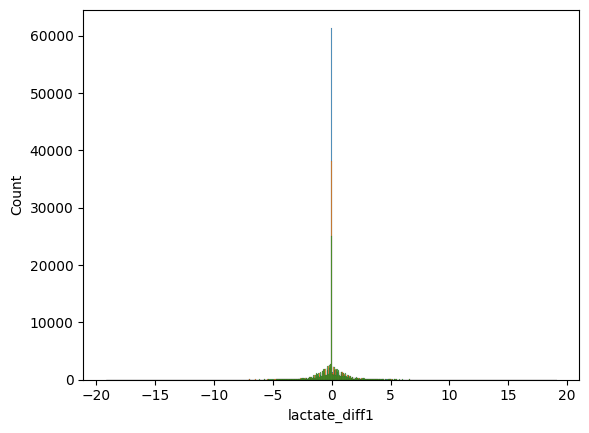

In [12]:
import seaborn as sns

sns.histplot(data["lactate_diff1"])
sns.histplot(data["lactate_diff2"])
sns.histplot(data["lactate_diff3"])

#number of lactates = 0:
# print((data["lactate"] < 0.011).sum())

In [16]:
data[data['stay_id'] == 36655599]

,stay_id,timestep,sepsis,age,gender,charlson_comorbidity_index,heart_rate,map,respiratory_rate,temp_C,...,lactate_min_16h,creatinine_min_16h,platelets_min_16h,sirs_score_min_16h,shock_index_min_16h,lactate_measured_min_16h,wbc_measured_min_16h,creatinine_measured_min_16h,platelets_measured_min_16h,target
89644,36655599,1,0,61.0,0,4,65.571426,107.599998,15.857142,36.420635,...,1.3,1.3,244.0,1.0,0.452217,0.0,1.0,1.0,1.0,1
